# INTRADAY OPTION VALUES AND GREEKS

In this notebook I show how you can analyse Vanilla European Call and Put Equity options

In [19]:
import numpy as np
import matplotlib.pyplot as plt

In [20]:
from financepy.utils.date import Date
from financepy.utils.date_format import set_date_format, DateFormatTypes

from financepy.utils.math import ONE_MILLION
from financepy.utils.global_types import OptionTypes
from financepy.utils.day_count import DayCountTypes
from financepy.utils.frequency import FrequencyTypes
from financepy.utils.calendar import CalendarTypes, BusDayAdjustTypes, DateGenRuleTypes

from financepy.models.black_scholes import BlackScholes
from financepy.products.equity import EquityVanillaOption
from financepy.market.curves.flat_discount_curve import FlatDiscountCurve


In [21]:
set_date_format(DateFormatTypes.DATETIME)

## Creating the Option

We need to set up the option details - what you would find in the Term Sheet.

Option expires at 11am

In [22]:
expiry_dt = Date(5, 1, 2021, 11, 0, 0)

In [23]:
strike_price = 100.0

We now create the option object

In [24]:
call_option = EquityVanillaOption(expiry_dt, strike_price, OptionTypes.EUROPEAN_CALL)

## Valuation Dates

In [25]:
value_dt = Date(1, 1, 2021, 1, 0, 0)

In [26]:
expiry_dt - value_dt

4.416666666671517

In [27]:
hours_to_expiry = int((expiry_dt - value_dt) * 24)

In [28]:
hours_to_expiry

106

In [29]:
value_dts = []
times = []

next_value_date = value_dt

for i in range(0, hours_to_expiry):
    next_value_date = next_value_date.add_hours(1)
    value_dts.append(next_value_date)
    time = (next_value_date - value_dt) * 24
    times.append(time)

In [30]:
value_dts

[01/01/2021 02:00:00,
 01/01/2021 03:00:00,
 01/01/2021 04:00:00,
 01/01/2021 05:00:00,
 01/01/2021 06:00:00,
 01/01/2021 07:00:00,
 01/01/2021 08:00:00,
 01/01/2021 09:00:00,
 01/01/2021 10:00:00,
 01/01/2021 11:00:00,
 01/01/2021 12:00:00,
 01/01/2021 13:00:00,
 01/01/2021 14:00:00,
 01/01/2021 15:00:00,
 01/01/2021 16:00:00,
 01/01/2021 17:00:00,
 01/01/2021 18:00:00,
 01/01/2021 19:00:00,
 01/01/2021 20:00:00,
 01/01/2021 21:00:00,
 01/01/2021 22:00:00,
 01/01/2021 23:00:00,
 02/01/2021 00:00:00,
 02/01/2021 01:00:00,
 02/01/2021 02:00:00,
 02/01/2021 03:00:00,
 02/01/2021 04:00:00,
 02/01/2021 05:00:00,
 02/01/2021 06:00:00,
 02/01/2021 07:00:00,
 02/01/2021 08:00:00,
 02/01/2021 09:00:00,
 02/01/2021 10:00:00,
 02/01/2021 11:00:00,
 02/01/2021 12:00:00,
 02/01/2021 13:00:00,
 02/01/2021 14:00:00,
 02/01/2021 15:00:00,
 02/01/2021 16:00:00,
 02/01/2021 17:00:00,
 02/01/2021 18:00:00,
 02/01/2021 19:00:00,
 02/01/2021 20:00:00,
 02/01/2021 21:00:00,
 02/01/2021 22:00:00,
 02/01/202

## Valuations

To do a valuation we need to specify the date and set the market inputs

In [31]:
stock_price = 98.0
dividend_yield = 0.02
interest_rate = 0.05

In [32]:
volatility = 0.20
model = BlackScholes(volatility)

For simplicity the discount curve is assumed to be flat here (we can pass in any discount curve) and is created as follows.

In [33]:
value_dt

01/01/2021 01:00:00

In [34]:
print(value_dt)
years = np.linspace(0.0, 5.0, 6)
df_dates = value_dt.add_years(years)
print(df_dates)

01/01/2021 01:00:00
[01/01/2021 01:00:00, 01/01/2022 01:00:00, 01/01/2023 01:00:00, 01/01/2024 01:00:00, 01/01/2025 01:00:00, 01/01/2026 01:00:00]


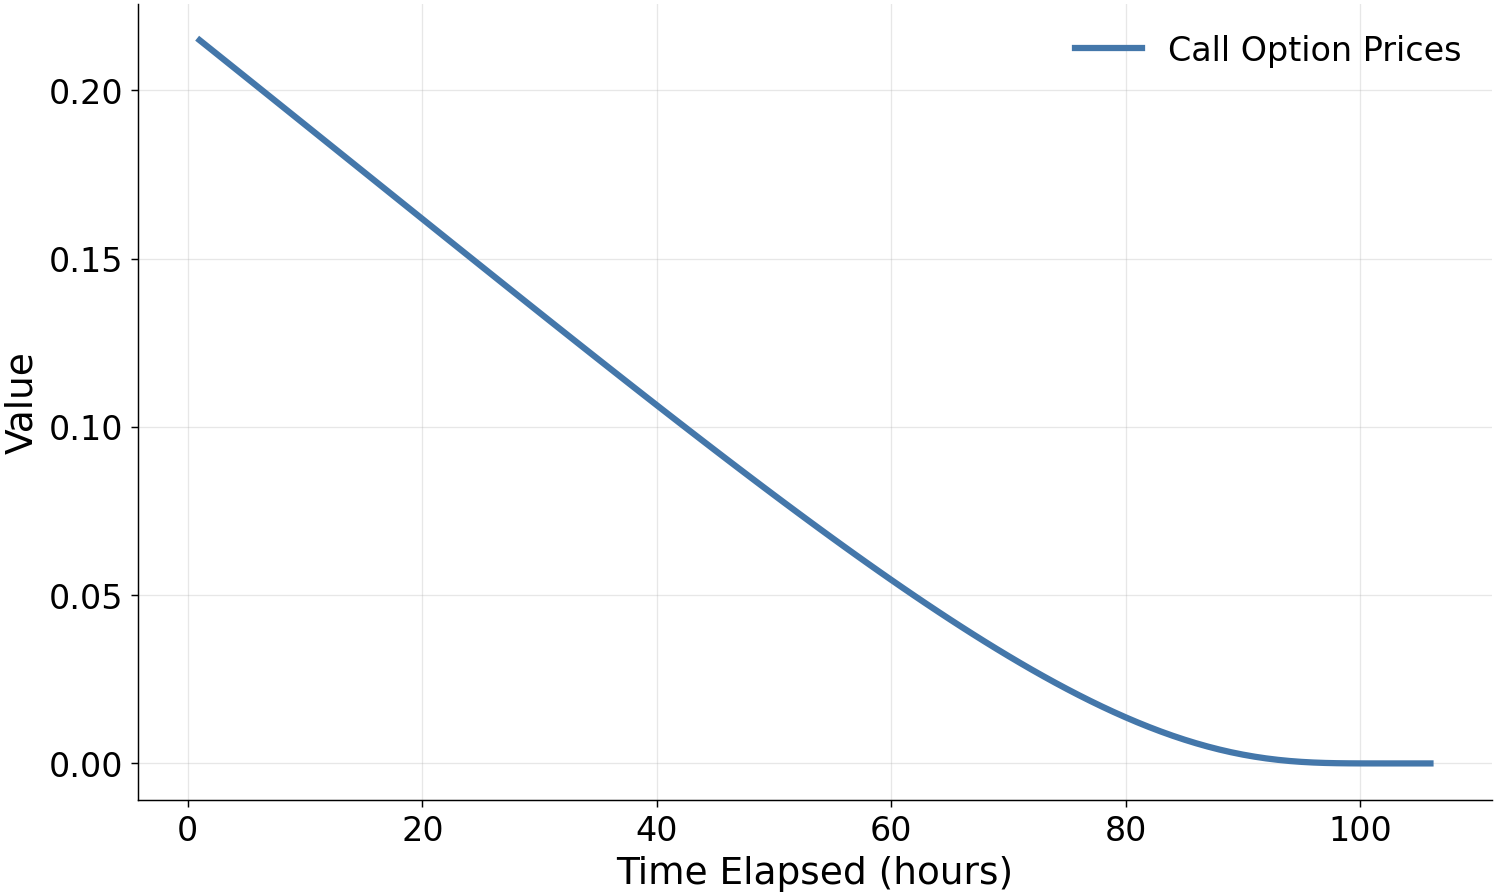

In [35]:
values = []
int_times = []

for dt in value_dts:
    discount_curve = FlatDiscountCurve(dt, interest_rate, FrequencyTypes.ANNUAL)
    dividend_curve = FlatDiscountCurve(dt, dividend_yield)
    call_value = call_option.value(dt, stock_price, discount_curve, dividend_curve, model)
    values.append(call_value)
    t = (call_option.expiry_dt - value_dt) / 365
    int_times.append(t)

plt.figure(figsize=(10,6))
plt.plot(times, values, label="Call Option Prices")
plt.xlabel("Time Elapsed (hours)")
plt.ylabel("Value")
plt.legend()
plt.grid()

# Risk Sensitivities

## Delta

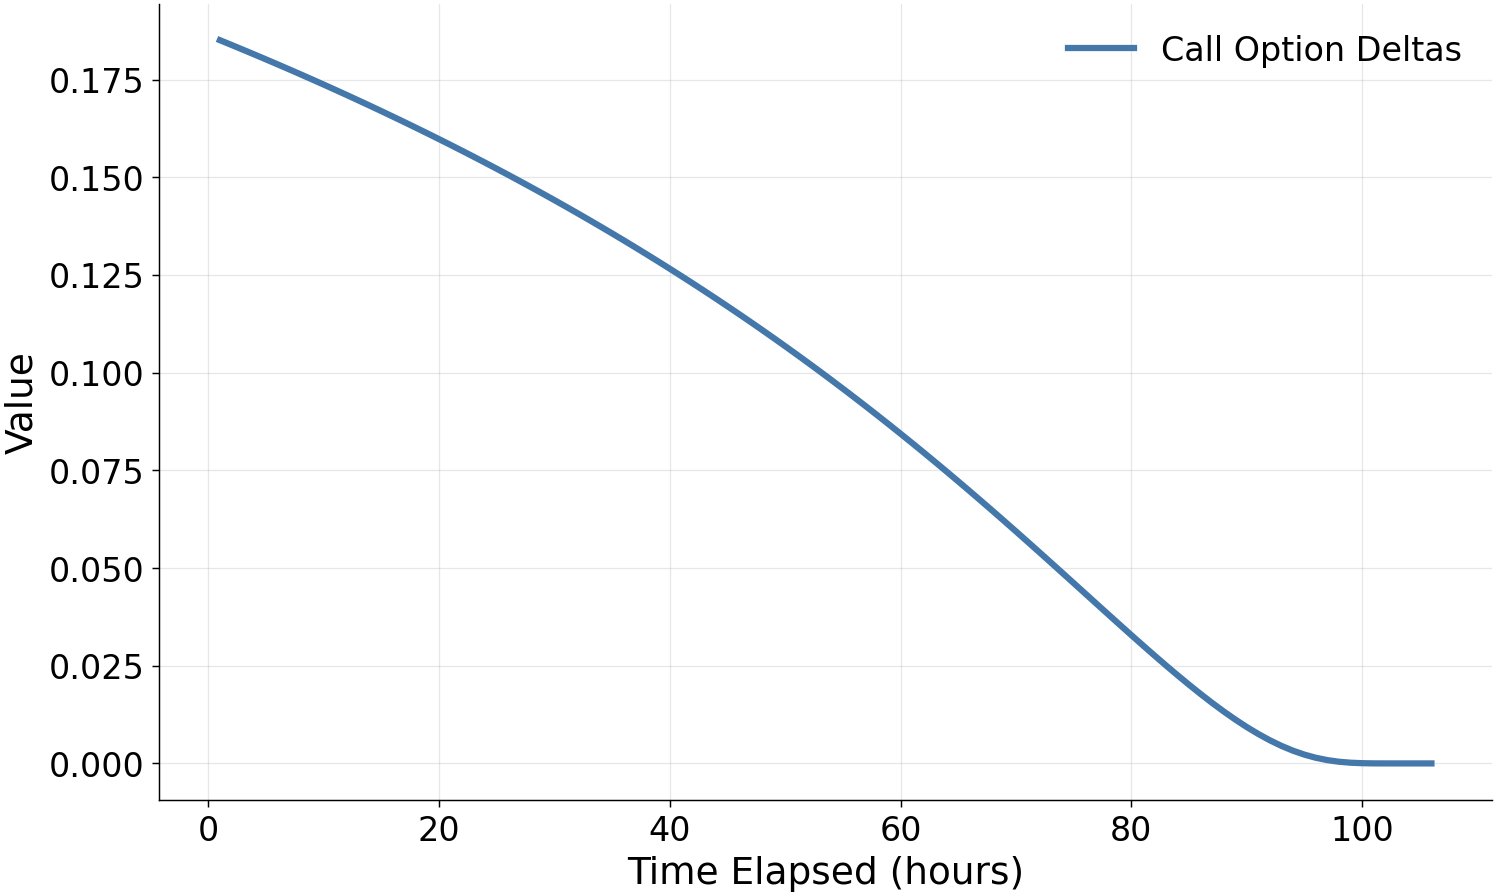

In [36]:
values = []

for value_dt in value_dts:
    discount_curve = FlatDiscountCurve(value_dt, interest_rate, FrequencyTypes.ANNUAL)
    dividend_curve = FlatDiscountCurve(value_dt, dividend_yield)
    delta = call_option.delta(value_dt, stock_price, discount_curve, dividend_curve, model)
    values.append(delta)

plt.figure(figsize=(10,6))
plt.plot(times, values, label="Call Option Deltas")
plt.xlabel("Time Elapsed (hours)")
plt.ylabel("Value")
plt.legend()
plt.grid()

## Gamma

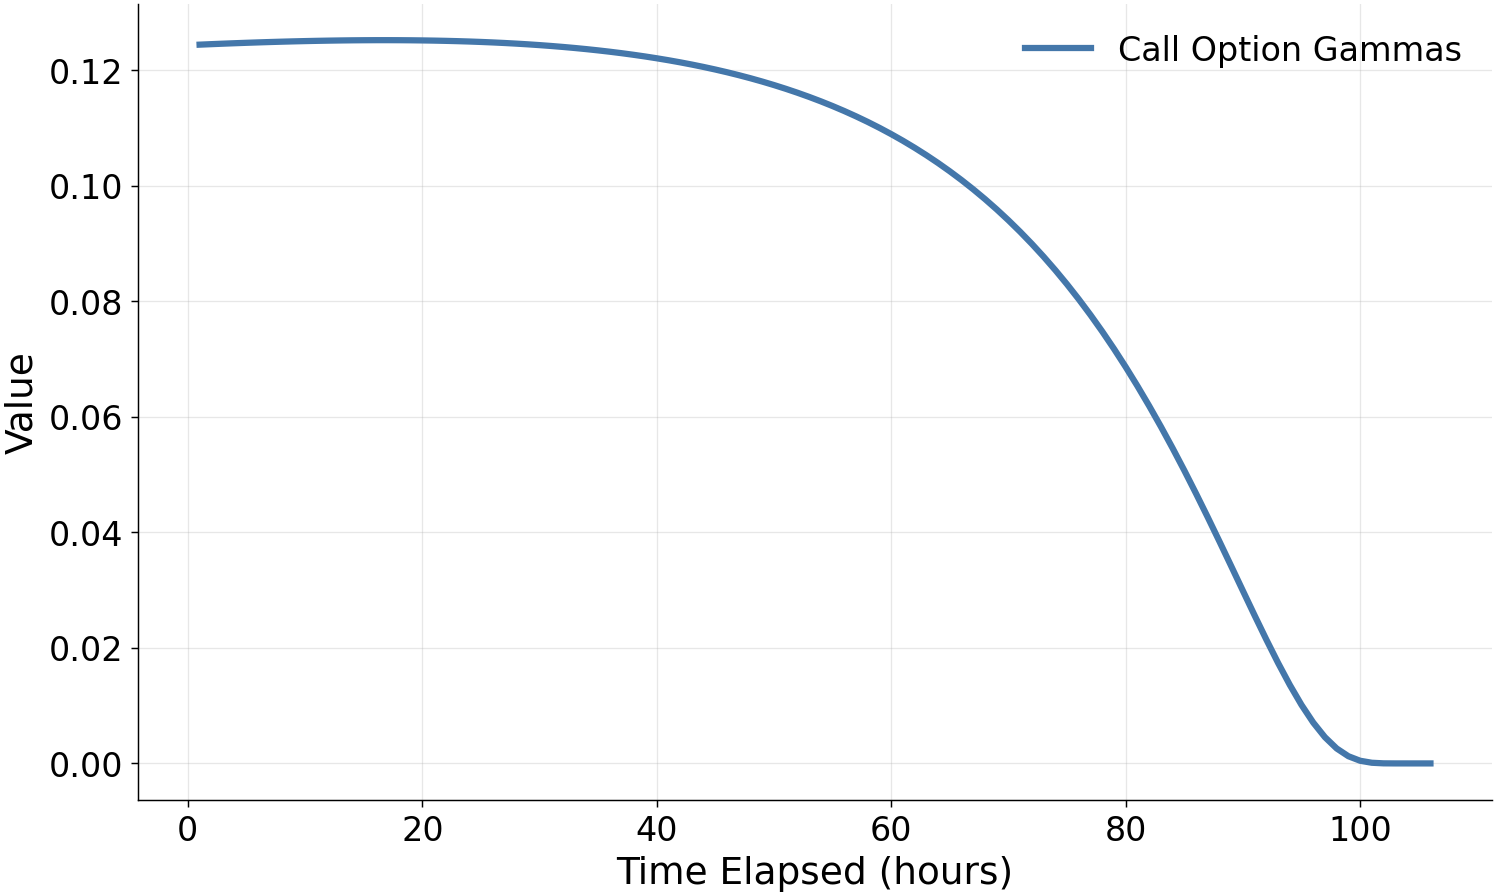

In [37]:
values = []
for value_dt in value_dts:
    discount_curve = FlatDiscountCurve(value_dt, interest_rate, FrequencyTypes.ANNUAL)
    dividend_curve = FlatDiscountCurve(value_dt, dividend_yield)
    call_value = call_option.gamma(value_dt, stock_price, discount_curve, dividend_curve, model)
    values.append(call_value)

plt.figure(figsize=(10,6))
plt.plot(times, values, label="Call Option Gammas")
plt.xlabel("Time Elapsed (hours)")
plt.ylabel("Value")
plt.legend()
plt.grid()

## Vega

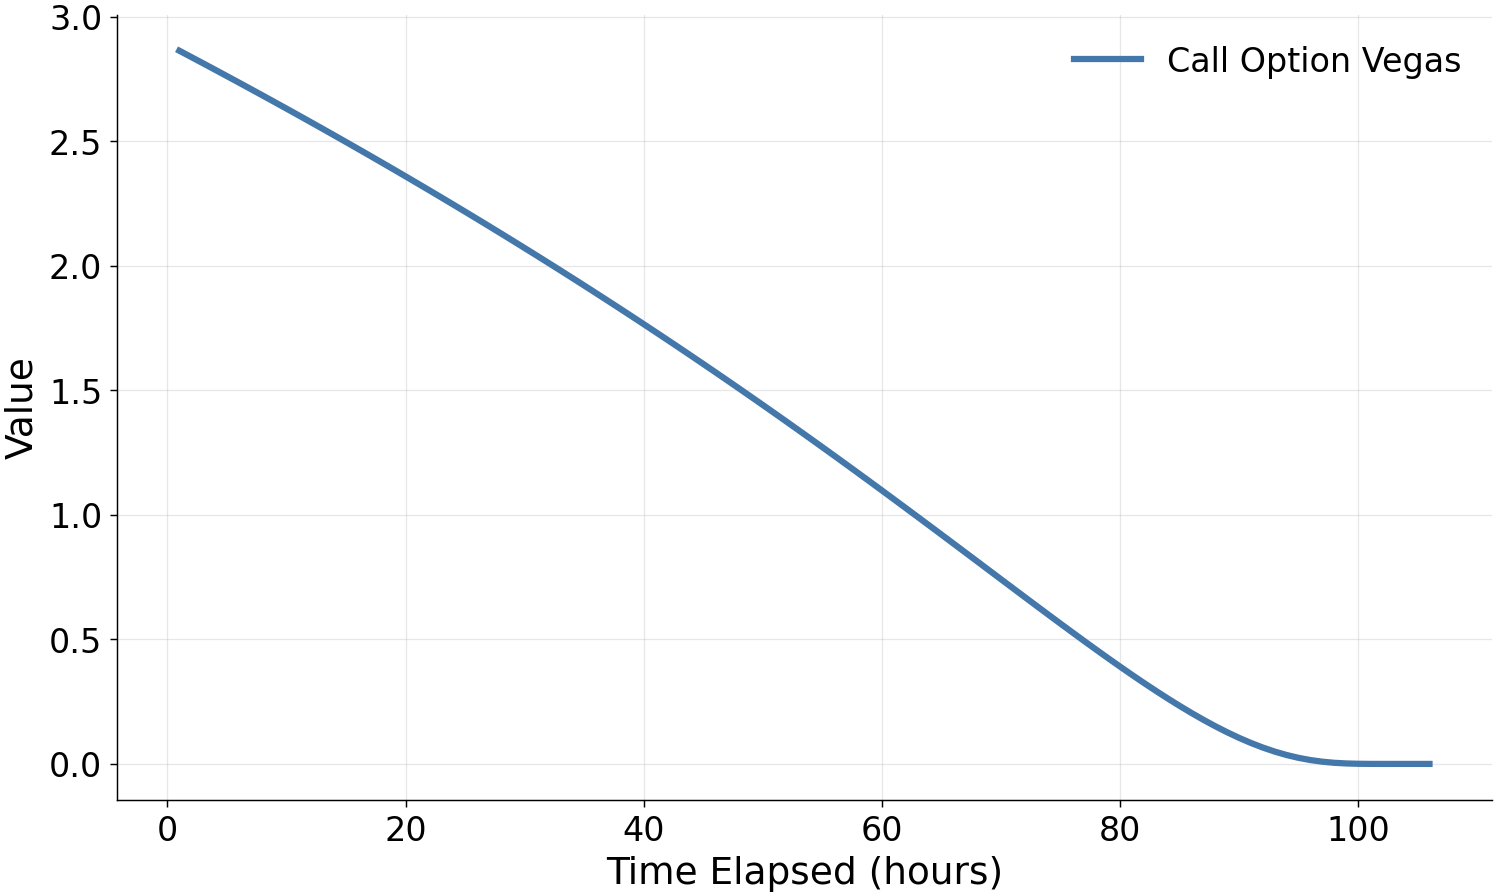

In [38]:
values = []
for value_dt in value_dts:
    discount_curve = FlatDiscountCurve(value_dt, interest_rate, FrequencyTypes.ANNUAL)
    dividend_curve = FlatDiscountCurve(value_dt, dividend_yield)
    call_value = call_option.vega(value_dt, stock_price, discount_curve, dividend_curve, model)
    values.append(call_value)

plt.figure(figsize=(10,6))
plt.plot(times, values, label="Call Option Vegas")
plt.xlabel("Time Elapsed (hours)")
plt.ylabel("Value")
plt.legend()
plt.grid()

## Theta

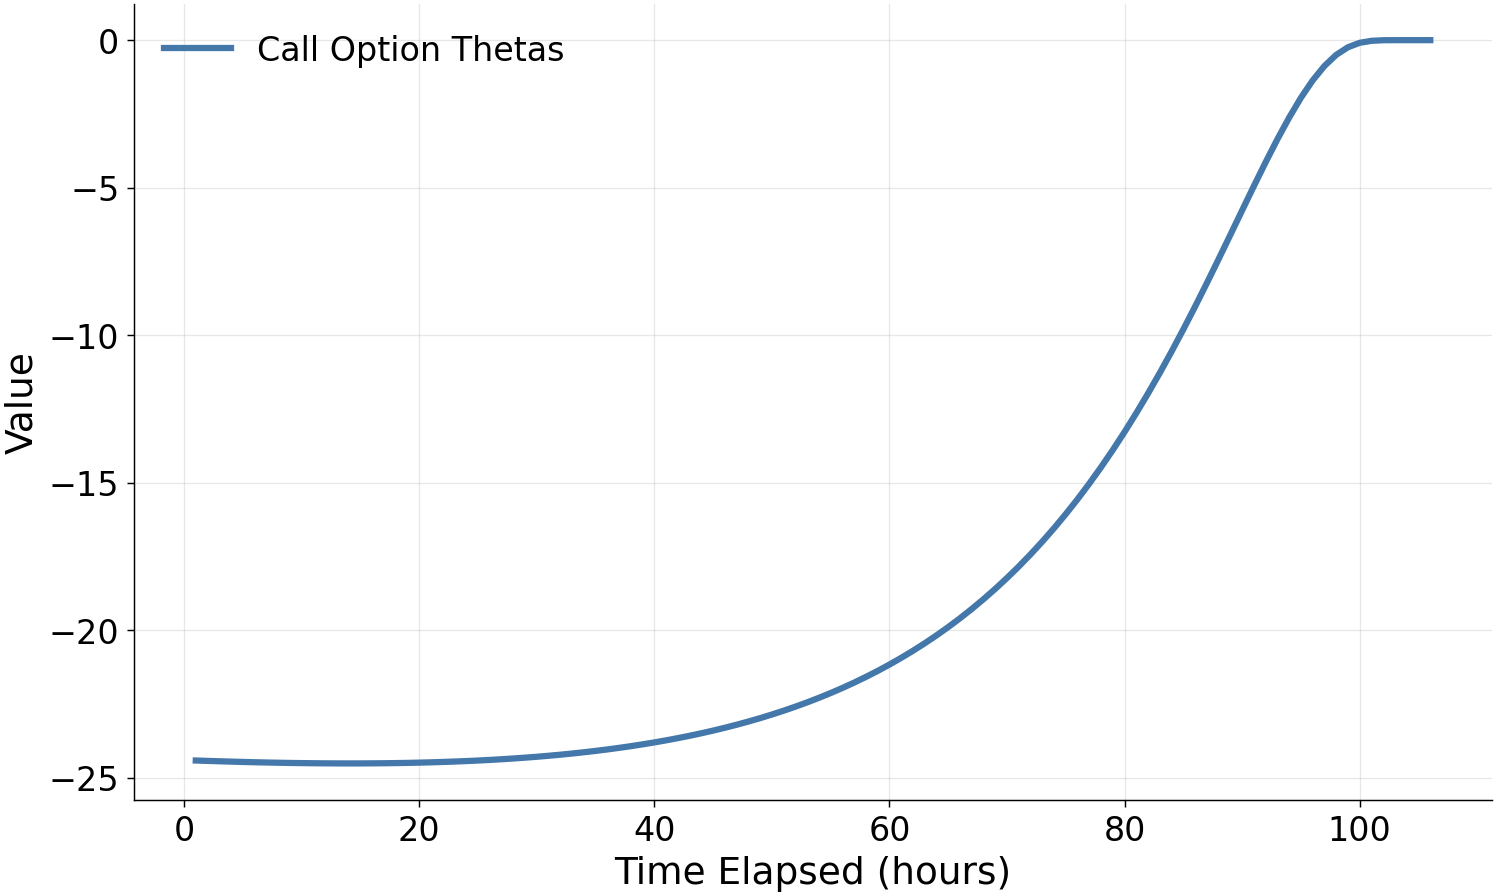

In [39]:
values = []
for value_dt in value_dts:
    discount_curve = FlatDiscountCurve(value_dt, interest_rate, FrequencyTypes.ANNUAL)
    dividend_curve = FlatDiscountCurve(value_dt, dividend_yield)
    call_value = call_option.theta(value_dt, stock_price, discount_curve, dividend_curve, model)
    values.append(call_value)

plt.figure(figsize=(10,6))
plt.plot(times, values, label="Call Option Thetas")
plt.xlabel("Time Elapsed (hours)")
plt.ylabel("Value")
plt.legend()
plt.grid()

## Rho

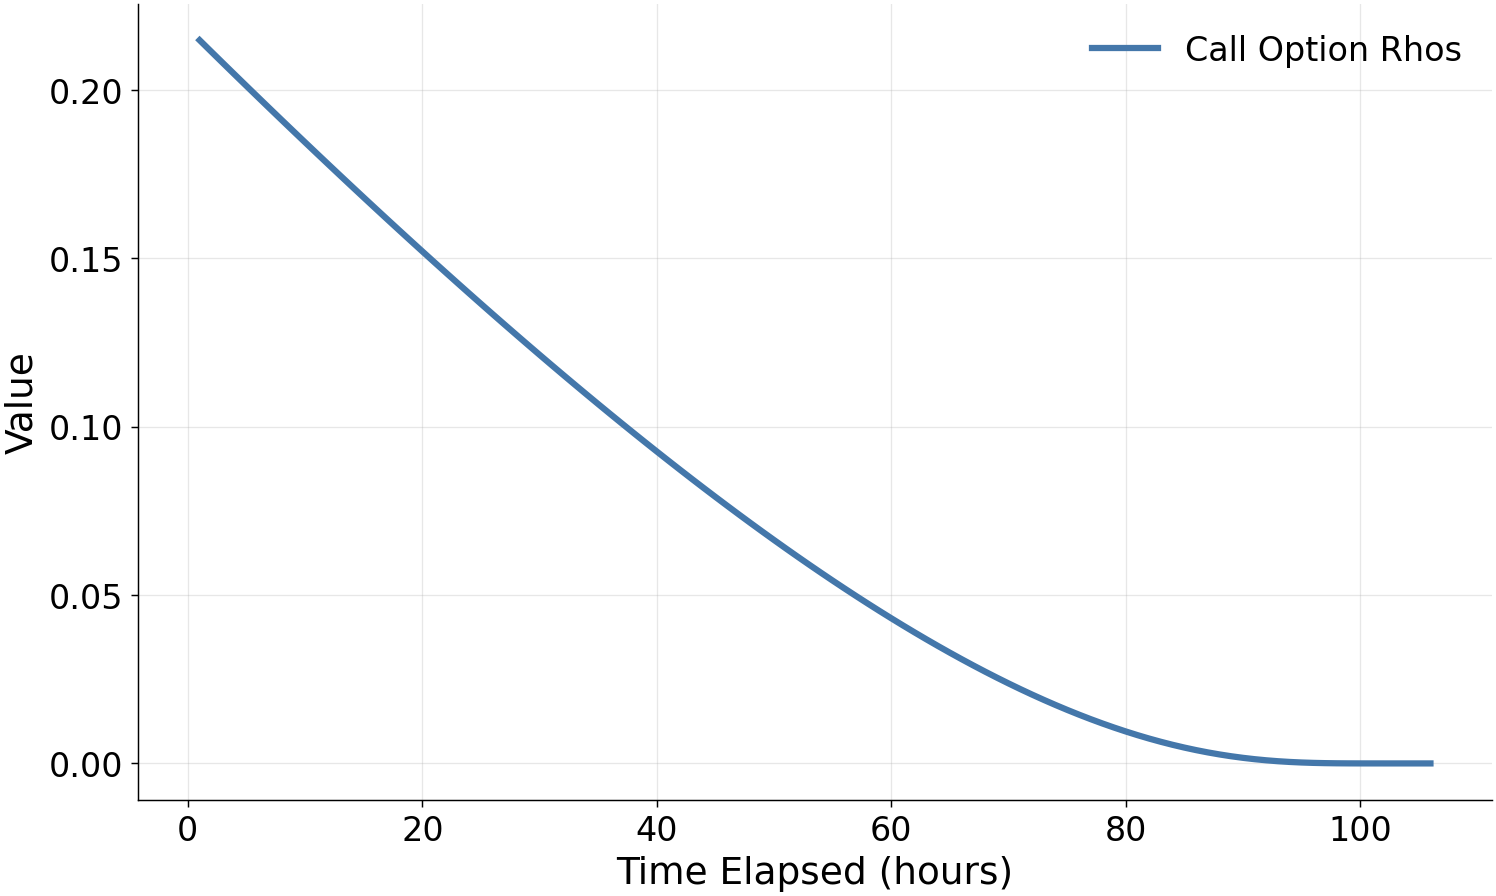

In [40]:
values = []
for value_dt in value_dts:
    discount_curve = FlatDiscountCurve(value_dt, interest_rate, FrequencyTypes.ANNUAL)
    dividend_curve = FlatDiscountCurve(value_dt, dividend_yield)
    call_value = call_option.rho(value_dt, stock_price, discount_curve, dividend_curve, model)
    values.append(call_value)

plt.figure(figsize=(10,6))
plt.plot(times, values, label="Call Option Rhos")
plt.xlabel("Time Elapsed (hours)")
plt.ylabel("Value")
plt.legend()
plt.grid()

Copyright (c) 2019, Dominic O'Kane 